# Semimetal to Mott insulator transition

This notebook uses [pyALF](https://github.com/ALF-QMC/pyALF) to simulate the **repulsive Hubbard model on the honeycomb lattice at half filling**. We vary the interaction strength and measure antiferromagnetic spin correlations on two lattice sizes. The aim is to connect the simulation workflow to the physics of the semimetal-to-Mott-insulator transition.

## The model and its transition

The Hamiltonian is

$$
\hat H = -t\sum_{\langle i,j\rangle,\sigma}
\left(\hat c^\dagger_{i, \sigma}\hat c_{j, \sigma}+\mathrm{h.c.}\right)
+\frac{U}{2} \sum_i \left(\sum_\sigma \hat n_{i,\sigma}-\frac12 \right)^2.
$$

Here $t$ is the nearest-neighbour hopping, $U>0$ is the on-site repulsion, and $\hat n_{i, \sigma}=\hat c^\dagger_{i, \sigma}\hat c_{i\sigma}$. The particle-hole-symmetric form makes zero chemical potential correspond to half filling: one electron per site on average. We use the default hopping $t=1$.

At weak interaction, the honeycomb lattice is a **Dirac semimetal**: the valence and conduction bands meet at isolated Dirac points, and the low-energy charge excitations are gapless. Increasing $U/t$ penalises double occupancy. At sufficiently strong repulsion, a charge gap opens and the ground state becomes an **antiferromagnetic Mott insulator**, with opposite spin orientations on the two sublattices. Deep in the insulating regime, virtual hopping produces an antiferromagnetic exchange $J\simeq 4t^2/U$ between local moments.

Large-scale studies find a direct, continuous zero-temperature transition near $U_c/t\approx 3.8$, associated with Gross–Neveu–Heisenberg criticality, in which Dirac fermions couple to a three-component antiferromagnetic order parameter. See [Assaad and Herbut (2013)](https://arxiv.org/abs/1304.6340) and [Parisen Toldin et al. (2015)](https://arxiv.org/abs/1411.2502). This is a literature result; the small lattices and short runs below illustrate the growth of correlations but do not determine the critical coupling or universality class.

## Import the tools

`Simulation` prepares and runs ALF, while `ALF_source` manages its source directory. We use `load_res` to collect analysed observables, `Lattice` to locate a momentum in ALF's lattice convention, and NumPy, pandas, and Matplotlib to organise and plot the results. Run the notebook from top to bottom after completing the [installation steps](../02-installation.md).


In [62]:
import matplotlib.pyplot as plt  # Plotting library
import numpy as np  # Numerical libary
from py_alf import ALF_source, Simulation, Lattice
from py_alf.ana import load_res  # Function for loading analysis results
# from py_alf.analysis import analysis  # Analysis function
from py_alf.utils import find_sim_dirs  # Function for finding QMC bins

from pathlib import Path
import pandas as pd
from collections import defaultdict

## Set the ALF source directory

`ALF_source` locates the ALF source checkout, downloading it if necessary, and selects the requested branch. The resulting `alf_src` object is shared by the compilation and simulation steps. Here we use `master`; for a reproducible study, also record the ALF and pyALF versions used.


In [63]:
alf_src = ALF_source(branch='master')

Checking out branch master
Your branch is up to date with 'origin/master'.


Already on 'master'


## Compile ALF

Create a `Simulation` object for the Hubbard Hamiltonian and compile the executable once. This step builds ALF but does not perform a Monte Carlo run. The same executable can then be reused for all lattice sizes and interaction strengths in the scan. Compilation requires the Fortran compiler and numerical libraries described in the installation section.


In [64]:
compile_sim = Simulation(alf_src=alf_src, ham_name='Hubbard',sim_dict={}) #sim_dict is used to choose parameters.
compile_sim.compile()

Checking out branch master
Your branch is up to date with 'origin/master'.


Already on 'master'


Compiling ALF... 
Cleaning up Prog/
Cleaning up Libraries/
Cleaning up Analysis/
Compiling Libraries


entanglement_mod.F90:35:2:

   35 | #warning "You are compiling entanglement without MPI. No Renyi entropy results possible, all other observables still work!"
      |  1~~~~~~
ar: creating archive modules_90.a
ar: creating archive libqrref.a


Compiling Analysis
Compiling Program
Compiling program modules
Parsing Hamiltonian parameters
filenames: Hamiltonians/Hamiltonian_Kondo_smod.F90 Hamiltonians/Hamiltonian_Kondo_read_write_parameters.F90
filenames: Hamiltonians/Hamiltonian_Hubbard_smod.F90 Hamiltonians/Hamiltonian_Hubbard_read_write_parameters.F90
filenames: Hamiltonians/Hamiltonian_Hubbard_Plain_Vanilla_smod.F90 Hamiltonians/Hamiltonian_Hubbard_Plain_Vanilla_read_write_parameters.F90
filenames: Hamiltonians/Hamiltonian_tV_smod.F90 Hamiltonians/Hamiltonian_tV_read_write_parameters.F90
filenames: Hamiltonians/Hamiltonian_LRC_smod.F90 Hamiltonians/Hamiltonian_LRC_read_write_parameters.F90
filenames: Hamiltonians/Hamiltonian_Z2_Matter_smod.F90 Hamiltonians/Hamiltonian_Z2_Matter_read_write_parameters.F90
filenames: Hamiltonians/Hamiltonian_Spin_Peierls_smod.F90 Hamiltonians/Hamiltonian_Spin_Peierls_read_write_parameters.F90
Link program
Done.


## Run the simulations

We scan $U/t=1,2,\ldots,7$ on periodic honeycomb lattices with $L=3$ and $L=6$. Each unit cell contains two sites, labelled $A$ and $B$, so the number of unit cells is $N=L^2$ and the number of sites is $N_s=2L^2$: 18 and 72 sites, respectively.

The main parameters are:

| Parameter | Meaning in this example |
| --- | --- |
| `Lattice_type`, `L1`, `L2` | Honeycomb geometry with $L\times L$ unit cells. |
| `ham_U`, `ham_chem` | Repulsive interaction $U>0$ and half filling at zero chemical potential. |
| `Beta` | Inverse temperature $\beta=1/T$; we choose $\beta t=L$, so larger lattices are also colder. |
| `NBin`, `Nsweep` | Ten measurement bins with ten Monte Carlo sweeps per bin, intended for a short demonstration. |
| `Mz=False` | A Hubbard–Stratonovich transformation coupling the auxiliary field to the density and preserving spin-rotation symmetry for each field configuration. |
| `N_SUN=2`, `N_FL=1` | The two physical spin states are represented as two colours sharing one fermion flavour. |
| `Checkerboard`, `Symm` | A symmetric checkerboard decomposition of imaginary-time evolution. The remaining finite-time-step error must still be checked. |
| `Ltau=0` | Measure equal-time observables only; time-displaced correlations are unnecessary for the plot below. |

The choice $\beta\propto L$ is motivated by the dynamical exponent $z=1$ at this quantum critical point. It fixes the space-time aspect ratio, but does not by itself establish ground-state convergence. The time step is not specified in the dictionary; the current ALF defaults give $\Delta\tau=0.1$.

For each $(L,U)$, `sim.run()` performs the simulation and `sim.analysis()` computes observable means and statistical errors. Each parameter set has its own directory. The directory prefix `Attractive_Hubbard` is only a name: the positive `ham_U` values here specify the **repulsive** model.


In [57]:
LAT_SIZES = [3, 6]
U_VALS = [i for i in np.arange(1.0, 8.0, 1.0)]

for U in U_VALS:
    for L in LAT_SIZES:
        sim = Simulation(
                    alf_src, 'Hubbard',
                    {
                        ### Choice of Predefined Model###
                        'Model': 'Hubbard',
                        
                        ###Definition of the Lattice###
                        'Lattice_type': 'Honeycomb',
                        'L1': L,
                        'L2': L,
                        
                        #--- Model parameters ---#
                        'Beta': L,
                        'ham_chem': 0.0,
                        'ham_U': U,
                        #--- Simulation parameters --- #
                        'Nsweep': 10,
                        'NBin': 10,
                        'Mz': False, #Choice of HS-Transformation (Exclusive for Hubbard-type interactions); ALF-DOC: 8.3.2 M_Z-Hubbard interaction
                        'Checkerboard': True, #ALF-DOC: 2.3. The Trotter error and checkerboard decomposition
                        'Symm': True, #Symmetric Trotter decomposition; ALF-DOC: 2.3. The Trotter error and checkerboard decomposition

                        ###ALF Internal Flags###
                        'N_SUN': 2, #
                        'N_FL': 1, # 
                        'Ltau': 0, #Speed up simulation by not calculating time-displaced observables, which take more time to compute.
                    },
                    machine='GNU',
                    sim_dir=f'Attractive_Hubbard_L{L}_U_{U}'
                )
        sim.run()
        sim.analysis()
print('All simulations and analyses complete.')

Prepare directory "/Users/jgci/PhD/ALF_devel/ALF_Tutorial/jupyterbook/source/04-nice-physics/ALF_data/Attractive_Hubbard_L3_U_1.0" for Monte Carlo run.
Create new directory.
Run /Users/jgci/PhD/ALF_devel/ALF_Tutorial/jupyterbook/source/04-nice-physics/ALF/Prog/ALF.out
 ALF Copyright (C) 2016 - 2022 The ALF project contributors
 This Program comes with ABSOLUTELY NO WARRANTY; for details see license.GPL
 This is free software, and you are welcome to redistribute it under certain conditions.
 No initial configuration
### Analyzing /Users/jgci/PhD/ALF_devel/ALF_Tutorial/jupyterbook/source/04-nice-physics/ALF_data/Attractive_Hubbard_L3_U_1.0 ###
/Users/jgci/PhD/ALF_devel/ALF_Tutorial/jupyterbook/source/04-nice-physics
Scalar observables:
Ener_scal
Kin_scal
Part_scal
Pot_scal
Histogram observables:
Equal time observables:
Den_eq
Green_eq
SpinZ_eq
Time displaced observables:
Prepare directory "/Users/jgci/PhD/ALF_devel/ALF_Tutorial/jupyterbook/source/04-nice-physics/ALF_data/Attractive_Hubba

## Load the analysed observables

`find_sim_dirs()` discovers simulation directories and `load_res(dirs)` combines their saved analysis results into a pandas table, with one row per simulation. If this working directory contains other runs, restrict `dirs` to the runs belonging to this scan before loading them.

We use `SpinZ_eqK` for the equal-time spin correlation matrix in momentum space, `SpinZ_eqK_err` for its estimated errors, and `SpinZ_eq_lattice` for the lattice information. The two matrix indices label the $A$ and $B$ sublattices; the last index labels momentum. Parameters such as `l1` and `ham_u` identify the lattice size and interaction strength of each row.


In [58]:
dirs = find_sim_dirs()
res=load_res(dirs)

./ALF_data/Attractive_Hubbard_L3_U_1.0
No orbital locations saved.
./ALF_data/Attractive_Hubbard_L3_U_2.0
No orbital locations saved.
./ALF_data/Attractive_Hubbard_L3_U_3.0
No orbital locations saved.
./ALF_data/Attractive_Hubbard_L3_U_4.0
No orbital locations saved.
./ALF_data/Attractive_Hubbard_L3_U_5.0
No orbital locations saved.
./ALF_data/Attractive_Hubbard_L3_U_6.0
No orbital locations saved.
./ALF_data/Attractive_Hubbard_L3_U_7.0
No orbital locations saved.
./ALF_data/Attractive_Hubbard_L6_U_1.0
No orbital locations saved.
./ALF_data/Attractive_Hubbard_L6_U_2.0
No orbital locations saved.
./ALF_data/Attractive_Hubbard_L6_U_3.0
No orbital locations saved.
./ALF_data/Attractive_Hubbard_L6_U_4.0
No orbital locations saved.
./ALF_data/Attractive_Hubbard_L6_U_5.0
No orbital locations saved.
./ALF_data/Attractive_Hubbard_L6_U_6.0
No orbital locations saved.
./ALF_data/Attractive_Hubbard_L6_U_7.0
No orbital locations saved.


## Extract antiferromagnetic correlations

The local spin is $\mathbf{\hat S}_{i,a}=\tfrac12\hat c^\dagger_{i,a,\alpha}\boldsymbol\sigma_{\alpha\beta}\hat c_{i,a,\beta}$, where $i$ labels a unit cell and $a\in\{A,B\}$. Néel order corresponds to the staggered combination

$$
\mathbf{\hat M}_i=\mathbf{\hat S}_{i,A}-\mathbf{\hat S}_{i,B}.
$$

The opposite signs are carried by the two sites **within** each unit cell. The pattern is uniform between unit cells, so its ordering momentum in the two-site description is $\mathbf\Gamma=(0,0)$.

Let $C_{ab}(\mathbf q)$ denote the sublattice matrix loaded from `SpinZ_eqK`. Projecting onto the staggered pattern gives

$$
S_{\mathrm{AFM}}(\mathbf q)
=C_{AA}(\mathbf q)+C_{BB}(\mathbf q)
-C_{AB}(\mathbf q)-C_{BA}(\mathbf q).
$$

The measured quantity is given by 

$$
S_{\mathrm{AFM}}(\mathbf q)
=\frac{1}{N}\sum_{i,j}
e^{-i\mathbf q\cdot(\mathbf r_i-\mathbf r_j)}
\langle\mathbf{\hat M}_i\cdot\mathbf{\hat M}_j\rangle.
$$

**Normalization of the existing plot.** The helper below returns $\sqrt{S_{\mathrm{AF}}^{\mathrm{ALF}}(\mathbf\Gamma)}$, which is labelled $m_{\mathrm{AFM}}$ in the plotting cell. This is the square root of a structure factor, not yet an intensive magnetisation per site. Defining the latter through

$$
m_s^2=\frac{1}{N}\sum_{i,j}
\langle\mathbf{\hat M}_i\cdot\mathbf{\hat M}_j\rangle,
\qquad
m_s=\sqrt{S_{\mathrm{AFM}}(\mathbf\Gamma)},
$$

`extract_pair_at_q` finds the requested momentum, combines the four sublattice entries, takes the square root, and groups results by $L$. 


In [59]:
def extract_pair_at_q(q: tuple, res: pd.DataFrame):
    plot_data = defaultdict(lambda: defaultdict(list))

    for _, row in res.iterrows():
        latt = Lattice(row["SpinZ_eq_lattice"])
        q_idx = latt.k_to_n(q)

        values = np.squeeze(row["SpinZ_eqK"][..., q_idx])
        errors = np.squeeze(row["SpinZ_eqK_err"][..., q_idx])

        spinZ = (
            values[0, 0] + values[1, 1]
            - values[0, 1] - values[1, 0]
        )
        spinZ_err = np.sqrt(
            errors[0, 0]**2 + errors[1, 1]**2
            + errors[0, 1]**2 + errors[1, 0]**2
        )

        sqrt_spinZ = np.sqrt(spinZ) if spinZ >= 0 else np.nan
        sqrt_spinZ_err = (
            spinZ_err / (2 * sqrt_spinZ) if spinZ > 0 else np.nan
        )

        L_key = f"L_{row['l1']}"
        plot_data[L_key]["L"] = row["l1"]
        plot_data[L_key]["U"].append(row["ham_u"])
        plot_data[L_key]["spinZ_value"].append(sqrt_spinZ)
        plot_data[L_key]["spinZ_err"].append(sqrt_spinZ_err)

    for entry in plot_data.values():
        for key in entry:
            entry[key] = np.asarray(entry[key])

    return plot_data

### Select the ordering momentum

Evaluate the helper at $\mathbf\Gamma=(0,0)$. The sublattice minus signs already select antiferromagnetism; choosing zero momentum here does not mean that we are measuring uniform ferromagnetic order.


In [60]:
plot_data = extract_pair_at_q((0.0, 0.0), res)

## Plot the interaction dependence

Plot the square root of the staggered structure factor against $U$ for each lattice size. Error bars show the approximate statistical uncertainty propagated by the helper above.


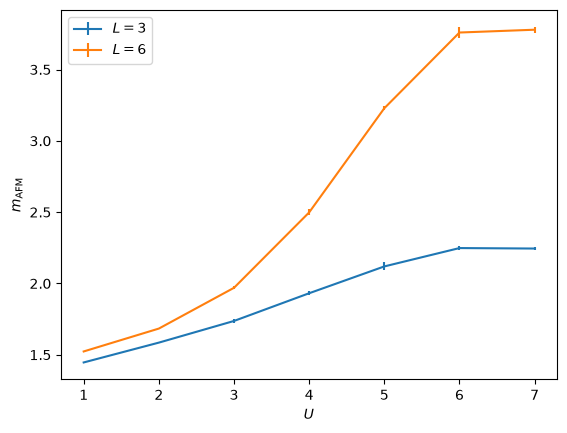

In [61]:
#Plot Order parameter first
plt.figure()
plt.xlabel(r"$U$")
plt.ylabel(r"$m_{\text{AFM}}$")

for L_key in plot_data.keys():
    L = plot_data[L_key]["L"]
    x_axis = plot_data[L_key]["U"]
    data = plot_data[L_key]["spinZ_value"]
    err = plot_data[L_key]["spinZ_err"]
    plt.errorbar(x_axis, data, yerr=err, label=fr"$L = {L}$")

plt.legend()
plt.show()

## Interpretation of the curves

An increase with $U$ indicates stronger antiferromagnetic correlations as double occupancy becomes energetically costly. A finite signal on a small lattice is expected even in the semimetal and is not by itself evidence of long-range order. Moreover, the raw structure factor grows with system size in an ordered state, so its square root cannot be compared directly as an intensive order parameter. Use the normalization given above before extrapolating $m_s$ towards $L\to\infty$.

The transition discussed here is a **zero-temperature quantum phase transition**. In two dimensions, this spin-rotation-invariant model has no spontaneous Néel order at nonzero temperature in the thermodynamic limit. The present finite-size, finite-temperature curves therefore show correlations approaching the ground-state behaviour, not a sharp thermal transition. At large $U$, the exchange scale $J=4t^2/U$ becomes small, so cooling relative to $J$ is especially important. Spin correlations diagnose the magnetic part of the transition; this notebook does not directly measure the charge gap.
